# One-Dimensional Gaussian Gradient-Flow Landscapes

**Credit.** This notebook is part of *Optimal Transport for Machine Learners* by [Gabriel Peyré](https://www.gpeyre.com/), CNRS and École normale supérieure, PSL University. The book and reproducible sources are available at [github.com/gpeyre/ot4ml](https://github.com/gpeyre/ot4ml).

**Copyright.** Copyright (c) 2025 Gabriel Peyré. Released under the MIT License; see the repository `LICENSE` file.

This notebook generates `fig:gradflow-gaussian-1d-energy-landscapes`. It compares four exact Wasserstein gradient flows that preserve the one-dimensional Gaussian family: relative entropy, squared Wasserstein distance, debiased Sinkhorn divergence, and relative Fisher information. Their restrictions to Gaussian measures become scalar energies on the half-plane of means and standard deviations.

In [1]:
# --- OT4ML_COLAB_BOOTSTRAP: make this figure notebook runnable standalone in Colab.
from pathlib import Path as _OT4ML_Path
import importlib.util as _OT4ML_importlib_util
import os as _OT4ML_os
import subprocess as _OT4ML_subprocess
import sys as _OT4ML_sys


def _ot4ml_find_repo_root():
    """Locate the OT4ML repository root for shared OT4ML assets.
    
    Returns:
        Repository root path located by the function.
    """
    here = _OT4ML_Path.cwd().resolve()
    for base in (here, *here.parents):
        if (base / "notebooks-figures" / "figure_style.py").exists():
            return base
        if base.name == "notebooks-figures" and (base / "figure_style.py").exists():
            return base.parent
    return None


def _ot4ml_ensure_package(module_name, package_name):
    """Install a package when the corresponding module is missing.
    
    Args:
        module_name: Python module name that should be importable.
        package_name: Package name to install when the module is unavailable.
    
    Returns:
        None. Imports the package if available, otherwise installs it first.
    """
    if _OT4ML_importlib_util.find_spec(module_name) is None:
        _OT4ML_subprocess.run(
            [_OT4ML_sys.executable, "-m", "pip", "install", "-q", package_name],
            check=True,
        )


ROOT = _ot4ml_find_repo_root()
if ROOT is None:
    ROOT = _OT4ML_Path("/content/ot4ml") if "google.colab" in _OT4ML_sys.modules else _OT4ML_Path.cwd() / "ot4ml"
    if ROOT.exists() and any(ROOT.iterdir()) and not (ROOT / ".git").exists():
        ROOT = ROOT.with_name(ROOT.name + "-repo")
    if not (ROOT / "notebooks-figures" / "figure_style.py").exists():
        _OT4ML_subprocess.run(
            ["git", "clone", "--depth", "1", "https://github.com/gpeyre/ot4ml.git", str(ROOT)],
            check=True,
        )

_OT4ML_os.chdir(ROOT)
_figures_path = str(ROOT / "notebooks-figures")
if _figures_path not in _OT4ML_sys.path:
    _OT4ML_sys.path.insert(0, _figures_path)

if "google.colab" in _OT4ML_sys.modules:
    pass


In [2]:
from pathlib import Path
import logging
import sys

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap

ROOT = Path.cwd()
if ROOT.name == "notebooks-figures":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "notebooks-figures"))

from figure_style import BLUE, RED, interp_color, figure_dir, save_pdf, setup_matplotlib

logging.getLogger("fontTools").setLevel(logging.ERROR)
setup_matplotlib()

NAME = "gradflow-gaussian-1d-energy-landscapes"
OUT = figure_dir(NAME)
THUMBNAIL = ROOT / "notebooks-figures" / "thumbnails" / f"{NAME}.png"
THUMBNAIL.parent.mkdir(parents=True, exist_ok=True)

TARGET_MEAN = 0.45
TARGET_STD = 1.00
SINKHORN_EPSILON = 1.20
MEAN_BOUNDS = (-1.20, 2.10)
STD_BOUNDS = (0.20, 3.50)
TARGET = np.array([TARGET_MEAN, TARGET_STD])

## Scalar energies

Write

$$
\alpha=\mathcal N(m,\sigma^2),
\qquad
\gamma=\mathcal N(\bar m,\bar\sigma^2).
$$

The Gaussian Wasserstein metric is Euclidean in $(m,\sigma)$:

$$
W_2^2\!\left(\mathcal N(m,\sigma^2),\mathcal N(m',({\sigma}')^2)\right)
=(m-m')^2+(\sigma-\sigma')^2.
$$

Consequently each Gaussian-preserving ambient Wasserstein flow displayed below obeys the ordinary Euclidean gradient system

$$
\dot m=-\partial_m g(m,\sigma),
\qquad
\dot\sigma=-\partial_\sigma g(m,\sigma).
$$

For the Sinkhorn divergence, the helper functions are

$$
\tau_\varepsilon(r)=\frac{\sqrt{\varepsilon^2+16r^2}-\varepsilon}{4r},
\qquad
\psi_\varepsilon(r)
=-2r\tau_\varepsilon(r)-\frac{\varepsilon}{2}\log\!\left(1-\tau_\varepsilon(r)^2\right).
$$

In [3]:
def sinkhorn_tau(r, epsilon=SINKHORN_EPSILON):
    """Evaluate the scalar Gaussian Sinkhorn correlation map.

    Args:
        r: Positive scalar or array of covariance cross-scales.
        epsilon: Entropic regularization strength.

    Returns:
        Array with the same shape as ``r`` containing ``tau_epsilon(r)``.
    """
    r = np.asarray(r, dtype=float)
    root = np.sqrt(epsilon**2 + 16.0 * r**2)
    return 4.0 * r / (root + epsilon)


def sinkhorn_psi(r, epsilon=SINKHORN_EPSILON):
    """Evaluate the scalar spectral term in Gaussian entropic OT.

    The algebraically equivalent expression below avoids subtracting
    ``tau_epsilon(r)**2`` from one when the regularization is small.

    Args:
        r: Positive scalar or array of covariance cross-scales.
        epsilon: Entropic regularization strength.

    Returns:
        Array with the same shape as ``r`` containing ``psi_epsilon(r)``.
    """
    r = np.asarray(r, dtype=float)
    root = np.sqrt(epsilon**2 + 16.0 * r**2)
    return -0.5 * (root - epsilon) - 0.5 * epsilon * np.log(
        2.0 * epsilon / (root + epsilon)
    )




The stable spectral helpers above are shared by the Sinkhorn energy and its flow. The following functions implement the four scalar landscapes directly from the formulas in the manuscript.

In [4]:
def kl_energy(mean, std):
    """Return KL(N(mean, std^2) | N(target_mean, target_std^2)).

    Args:
        mean: Mean coordinate, scalar or array.
        std: Positive standard-deviation coordinate, scalar or array.

    Returns:
        Relative entropy evaluated elementwise.
    """
    delta = mean - TARGET_MEAN
    return (
        np.log(TARGET_STD / std)
        + (std**2 + delta**2) / (2.0 * TARGET_STD**2)
        - 0.5
    )


def wasserstein_energy(mean, std):
    """Return the squared W2 distance to the target Gaussian.

    Args:
        mean: Mean coordinate, scalar or array.
        std: Positive standard-deviation coordinate, scalar or array.

    Returns:
        Squared Gaussian Wasserstein distance evaluated elementwise.
    """
    return (mean - TARGET_MEAN) ** 2 + (std - TARGET_STD) ** 2


def sinkhorn_energy(mean, std):
    """Return the debiased Gaussian Sinkhorn divergence.

    Args:
        mean: Mean coordinate, scalar or array.
        std: Positive standard-deviation coordinate, scalar or array.

    Returns:
        Debiased Sinkhorn divergence for the squared Euclidean ground cost.
    """
    covariance_term = (
        sinkhorn_psi(std * TARGET_STD)
        - 0.5 * sinkhorn_psi(std**2)
        - 0.5 * sinkhorn_psi(TARGET_STD**2)
    )
    return (mean - TARGET_MEAN) ** 2 + covariance_term


def fisher_energy(mean, std):
    """Return the Fisher information relative to the target Gaussian.

    Args:
        mean: Mean coordinate, scalar or array.
        std: Positive standard-deviation coordinate, scalar or array.

    Returns:
        Relative Fisher information evaluated elementwise.
    """
    delta = mean - TARGET_MEAN
    return (
        delta**2 / TARGET_STD**4
        + (std**2 - TARGET_STD**2) ** 2 / (std**2 * TARGET_STD**4)
    )


## Well-spread initial conditions

A large random candidate cloud is reduced by farthest-point sampling. This yields reproducible initial conditions that cover the displayed half-plane without creating a visible lattice.

In [5]:
def well_spread_initial_conditions(
    n_points=48, seed=51, n_candidates=6000, boundary_fraction=0.025
):
    """Select reproducible, well-spread initial Gaussian parameters.

    Args:
        n_points: Number of initial conditions retained by farthest sampling.
        seed: Seed for the candidate-point generator.
        n_candidates: Number of random candidates before subsampling.
        boundary_fraction: Relative inset from each displayed boundary.

    Returns:
        Array of shape ``(n_points, 2)`` whose columns are mean and standard
        deviation. Points too close to the target are excluded.
    """
    rng = np.random.default_rng(seed)
    mean_margin = boundary_fraction * (MEAN_BOUNDS[1] - MEAN_BOUNDS[0])
    std_margin = boundary_fraction * (STD_BOUNDS[1] - STD_BOUNDS[0])
    candidates = np.column_stack(
        [
            rng.uniform(
                MEAN_BOUNDS[0] + mean_margin,
                MEAN_BOUNDS[1] - mean_margin,
                n_candidates,
            ),
            rng.uniform(
                STD_BOUNDS[0] + std_margin,
                STD_BOUNDS[1] - std_margin,
                n_candidates,
            ),
        ]
    )
    candidates = candidates[np.linalg.norm(candidates - TARGET, axis=1) > 0.28]

    first = int(np.argmax(np.linalg.norm(candidates - TARGET, axis=1)))
    selected = [first]
    nearest_dist2 = np.sum((candidates - candidates[first]) ** 2, axis=1)
    for _ in range(1, n_points):
        index = int(np.argmax(nearest_dist2))
        selected.append(index)
        dist2 = np.sum((candidates - candidates[index]) ** 2, axis=1)
        nearest_dist2 = np.minimum(nearest_dist2, dist2)
    return candidates[np.asarray(selected)]


INITIAL_PARAMETERS = well_spread_initial_conditions()




## Closed-form trajectories

For KL, squared Wasserstein distance, and relative Fisher information, the scalar ODEs can be solved exactly. For example,

$$
\begin{aligned}
 m_t^{\rm KL}-\bar m
 &=e^{-t/\bar\sigma^2}(m_{t=0}-\bar m),
 & (\sigma_t^{\rm KL})^2
 &=\bar\sigma^2+e^{-2t/\bar\sigma^2}(\sigma_{t=0}^2-\bar\sigma^2),\\
 m_t^{W_2}-\bar m
 &=e^{-2t}(m_{t=0}-\bar m),
 & \sigma_t^{W_2}-\bar\sigma
 &=e^{-2t}(\sigma_{t=0}-\bar\sigma),\\
 m_t^{\rm F}-\bar m
 &=e^{-2t/\bar\sigma^4}(m_{t=0}-\bar m),
 & (\sigma_t^{\rm F})^4
 &=\bar\sigma^4+e^{-8t/\bar\sigma^4}(\sigma_{t=0}^4-\bar\sigma^4).
\end{aligned}
$$

In [6]:
def kl_trajectories(times):
    """Evaluate all exact KL gradient-flow trajectories.

    Args:
        times: One-dimensional array of nonnegative integration times.

    Returns:
        Array of shape ``(n_initial, n_times, 2)`` containing ``(m_t, sigma_t)``.
    """
    mean = TARGET_MEAN + (INITIAL_PARAMETERS[:, 0, None] - TARGET_MEAN) * np.exp(
        -times[None, :] / TARGET_STD**2
    )
    variance = TARGET_STD**2 + (
        INITIAL_PARAMETERS[:, 1, None] ** 2 - TARGET_STD**2
    ) * np.exp(-2.0 * times[None, :] / TARGET_STD**2)
    return np.stack([mean, np.sqrt(variance)], axis=-1)


def wasserstein_trajectories(times):
    """Evaluate all exact squared-Wasserstein gradient-flow trajectories.

    Args:
        times: One-dimensional array of nonnegative integration times.

    Returns:
        Array of shape ``(n_initial, n_times, 2)`` containing ``(m_t, sigma_t)``.
    """
    decay = np.exp(-2.0 * times)[None, :]
    mean = TARGET_MEAN + (INITIAL_PARAMETERS[:, 0, None] - TARGET_MEAN) * decay
    std = TARGET_STD + (INITIAL_PARAMETERS[:, 1, None] - TARGET_STD) * decay
    return np.stack([mean, std], axis=-1)


def fisher_trajectories(times):
    """Evaluate all exact relative-Fisher gradient-flow trajectories.

    Args:
        times: One-dimensional array of nonnegative integration times.

    Returns:
        Array of shape ``(n_initial, n_times, 2)`` containing ``(m_t, sigma_t)``.
    """
    mean = TARGET_MEAN + (INITIAL_PARAMETERS[:, 0, None] - TARGET_MEAN) * np.exp(
        -2.0 * times[None, :] / TARGET_STD**4
    )
    fourth_moment = TARGET_STD**4 + (
        INITIAL_PARAMETERS[:, 1, None] ** 4 - TARGET_STD**4
    ) * np.exp(-8.0 * times[None, :] / TARGET_STD**4)
    return np.stack([mean, np.power(fourth_moment, 0.25)], axis=-1)




## Sinkhorn trajectory

Only the scalar Sinkhorn standard-deviation equation is integrated numerically:

$$
\dot\sigma
=2\left[
\bar\sigma\tau_\varepsilon(\sigma\bar\sigma)
-\sigma\tau_\varepsilon(\sigma^2)
\right]
=
\frac{8\sigma(\bar\sigma^2-\sigma^2)}
{\sqrt{\varepsilon^2+16\sigma^2\bar\sigma^2}
 +\sqrt{\varepsilon^2+16\sigma^4}}.
$$

The rationalized form reveals the direction of motion and avoids cancellation near $\sigma=\bar\sigma$. A vectorized fourth-order Runge--Kutta scheme is sufficient because this is a smooth one-dimensional ODE on $\sigma>0$.

In [7]:
def sinkhorn_std_velocity(std):
    """Evaluate the Sinkhorn descent velocity in the standard deviation.

    Args:
        std: Positive standard deviations, scalar or array.

    Returns:
        Standard-deviation component of the Euclidean gradient flow,
        evaluated in a cancellation-free form.
    """
    cross_root = np.sqrt(
        SINKHORN_EPSILON**2 + 16.0 * std**2 * TARGET_STD**2
    )
    self_root = np.sqrt(SINKHORN_EPSILON**2 + 16.0 * std**4)
    return 8.0 * std * (TARGET_STD**2 - std**2) / (cross_root + self_root)


def sinkhorn_trajectories(times):
    """Integrate all Gaussian Sinkhorn gradient-flow trajectories.

    Args:
        times: Uniform one-dimensional array of nonnegative integration times.

    Returns:
        Array of shape ``(n_initial, n_times, 2)`` containing ``(m_t, sigma_t)``.

    Raises:
        ValueError: If the supplied time grid is not uniform.
    """
    time_steps = np.diff(times)
    if not np.allclose(time_steps, time_steps[0]):
        raise ValueError("The vectorized Runge--Kutta solver requires a uniform grid.")

    mean = TARGET_MEAN + (INITIAL_PARAMETERS[:, 0, None] - TARGET_MEAN) * np.exp(
        -2.0 * times[None, :]
    )
    std = np.empty((len(INITIAL_PARAMETERS), len(times)))
    std[:, 0] = INITIAL_PARAMETERS[:, 1]
    step = float(time_steps[0])
    for index in range(len(times) - 1):
        current = std[:, index]
        k1 = sinkhorn_std_velocity(current)
        k2 = sinkhorn_std_velocity(current + 0.5 * step * k1)
        k3 = sinkhorn_std_velocity(current + 0.5 * step * k2)
        k4 = sinkhorn_std_velocity(current + step * k3)
        std[:, index + 1] = current + step * (k1 + 2.0 * k2 + 2.0 * k3 + k4) / 6.0
    return np.stack([mean, std], axis=-1)


## Gradient verification

The plotted ODEs are checked independently against centered finite differences of the four scalar energies. This catches normalization errors, especially the factors of two in the unhalved squared Wasserstein and Sinkhorn objectives.

In [8]:
def finite_difference_descent(energy, parameters, step=1e-6):
    """Approximate the negative Euclidean gradient of a scalar energy.

    Args:
        energy: Callable accepting vectorized mean and standard-deviation arrays.
        parameters: Array of shape ``(n_points, 2)`` in the positive half-plane.
        step: Centered finite-difference increment.

    Returns:
        Array of shape ``(n_points, 2)`` approximating ``-grad energy``.
    """
    parameters = np.asarray(parameters, dtype=float)
    descent = np.empty_like(parameters)
    for axis in range(2):
        plus = parameters.copy()
        minus = parameters.copy()
        plus[:, axis] += step
        minus[:, axis] -= step
        descent[:, axis] = -(
            energy(plus[:, 0], plus[:, 1])
            - energy(minus[:, 0], minus[:, 1])
        ) / (2.0 * step)
    return descent


def exact_parameter_velocity(name, parameters):
    """Evaluate one analytic Gaussian parameter-flow vector field.

    Args:
        name: One of ``"kl"``, ``"w2"``, ``"sinkhorn"``, or ``"fisher"``.
        parameters: Array of shape ``(n_points, 2)`` containing ``(m, sigma)``.

    Returns:
        Array of analytic descent velocities with the same shape.

    Raises:
        ValueError: If ``name`` does not identify one of the four flows.
    """
    mean = parameters[:, 0]
    std = parameters[:, 1]
    delta = mean - TARGET_MEAN
    if name == "kl":
        return np.column_stack(
            [-delta / TARGET_STD**2, 1.0 / std - std / TARGET_STD**2]
        )
    if name == "w2":
        return np.column_stack([-2.0 * delta, -2.0 * (std - TARGET_STD)])
    if name == "sinkhorn":
        return np.column_stack([-2.0 * delta, sinkhorn_std_velocity(std)])
    if name == "fisher":
        return np.column_stack(
            [
                -2.0 * delta / TARGET_STD**4,
                2.0 / std**3 - 2.0 * std / TARGET_STD**4,
            ]
        )
    raise ValueError(f"Unknown flow name: {name}")


checks = [
    ("kl", kl_energy),
    ("w2", wasserstein_energy),
    ("sinkhorn", sinkhorn_energy),
    ("fisher", fisher_energy),
]
check_parameters = INITIAL_PARAMETERS[::3]
for name, energy in checks:
    exact = exact_parameter_velocity(name, check_parameters)
    numerical = finite_difference_descent(energy, check_parameters)
    relative_error = np.max(
        np.linalg.norm(exact - numerical, axis=1)
        / np.maximum(1.0, np.linalg.norm(exact, axis=1))
    )
    if relative_error > 2e-6:
        raise RuntimeError(f"{name}: gradient check failed with error {relative_error:.3e}.")
    print(f"{name}: relative gradient error={relative_error:.3e}")

kl: relative gradient error=3.012e-10
w2: relative gradient error=2.185e-10
sinkhorn: relative gradient error=2.659e-10
fisher: relative gradient error=2.136e-10


## Four-panel phase portrait

Each panel uses its own logarithmically compressed energy scale so that its level sets occupy the full visual range. The axes and initial conditions are shared. Segment colors remain monotone in time, but a concave color reparameterization makes the early blue, intermediate violet, and late red portions simultaneously visible.

In [9]:
PANEL_SPECS = [
    (r"$\mathrm{KL}$", kl_energy, kl_trajectories, 7.5),
    (r"$\mathcal{W}_2^2$", wasserstein_energy, wasserstein_trajectories, 4.4),
    (r"Sinkhorn, $\varepsilon=1.2$", sinkhorn_energy, sinkhorn_trajectories, 6.5),
    (r"$\mathcal{I}(\alpha|\gamma)$", fisher_energy, fisher_trajectories, 4.0),
]


def energy_display_scale(energy_values):
    """Compress an energy landscape while preserving all level sets.

    Args:
        energy_values: Two-dimensional array of nonnegative energy values.

    Returns:
        Logarithmically compressed values and strictly increasing filled and
        line-contour levels.
    """
    energy_values = np.maximum(np.asarray(energy_values, dtype=float), 0.0)
    reference = max(float(np.quantile(energy_values, 0.38)), 1e-12)
    display_values = np.log1p(energy_values / reference)
    filled_levels = np.unique(
        np.quantile(display_values, [0.00, 0.12, 0.25, 0.40, 0.56, 0.70, 0.82, 0.91, 0.97, 1.00])
    )
    line_levels = np.unique(
        np.quantile(display_values, [0.16, 0.30, 0.45, 0.60, 0.73, 0.84, 0.92, 0.97])
    )
    return display_values, filled_levels, line_levels


def time_colors(times):
    """Map increasing physical times to the OT4ML blue-to-red palette.

    Args:
        times: Increasing time grid used by one trajectory family.

    Returns:
        List of RGB colors, one for each trajectory segment.
    """
    mid_times = 0.5 * (times[:-1] + times[1:])
    normalized = np.power(mid_times / times[-1], 0.40)
    return [interp_color(value, BLUE, RED) for value in normalized]




The background levels are computed independently in each panel. The next helper overlays the shared initial points, colored trajectories, and common target while preserving identical axes.

In [10]:
mean_grid = np.linspace(*MEAN_BOUNDS, 360)
std_grid = np.linspace(*STD_BOUNDS, 360)
MEAN_GRID, STD_GRID = np.meshgrid(mean_grid, std_grid)
energy_cmap = LinearSegmentedColormap.from_list(
    "gaussian_energy", ["#ffffff", "#f3f0e9", "#d7d0c4"]
)


def draw_energy_background(ax, energy):
    """Render the filled energy landscape and its contour lines.

    Args:
        ax: Matplotlib axes receiving the background.
        energy: Callable evaluating the scalar energy on array inputs.

    Returns:
        None. The supplied axes are modified in place.
    """
    display_energy, filled_levels, line_levels = energy_display_scale(
        energy(MEAN_GRID, STD_GRID)
    )
    ax.contourf(
        MEAN_GRID,
        STD_GRID,
        display_energy,
        levels=filled_levels,
        cmap=energy_cmap,
        extend="max",
        zorder=0,
    )
    ax.contour(
        MEAN_GRID,
        STD_GRID,
        display_energy,
        levels=line_levels,
        colors="#9f9688",
        linewidths=0.38,
        alpha=0.75,
        zorder=0.5,
    )


The trajectory overlay is kept separate from the contour rendering so that its time coloring and endpoint annotations can be audited independently.

In [11]:
def draw_flow_overlay(ax, title, trajectory_solver, final_time):
    """Overlay time-colored trajectories, endpoints, and axes styling.

    Args:
        ax: Matplotlib axes receiving the trajectories.
        title: Short mathematical title displayed above the panel.
        trajectory_solver: Callable returning trajectories on a time grid.
        final_time: Last physical integration time shown by the panel.

    Returns:
        None. The supplied axes are modified in place.
    """
    times = np.linspace(0.0, final_time, 220)
    trajectories = trajectory_solver(times)
    segment_colors = time_colors(times)
    for trajectory in trajectories:
        segments = np.stack([trajectory[:-1], trajectory[1:]], axis=1)
        ax.add_collection(
            LineCollection(
                segments,
                colors=segment_colors,
                linewidths=0.70,
                alpha=0.88,
                zorder=2,
            )
        )

    ax.scatter(
        INITIAL_PARAMETERS[:, 0],
        INITIAL_PARAMETERS[:, 1],
        s=3.4,
        color=BLUE,
        edgecolor="white",
        linewidth=0.16,
        zorder=3,
    )
    ax.scatter(
        [TARGET_MEAN],
        [TARGET_STD],
        s=22.0,
        color=RED,
        edgecolor="white",
        linewidth=0.65,
        zorder=5,
    )
    ax.annotate(
        r"$(\bar m,\bar\sigma)$",
        xy=(TARGET_MEAN, TARGET_STD),
        xytext=(4.0, 5.0),
        textcoords="offset points",
        color=RED,
        fontsize=6.4,
        bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.48, "pad": 0.35},
        zorder=6,
    )

    ax.set_title(title, fontsize=9.0, pad=3.5)
    ax.set_xlabel(r"$m$", labelpad=1.0)
    ax.set_xlim(MEAN_BOUNDS)
    ax.set_ylim(STD_BOUNDS)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xticks([-1.0, 0.0, 1.0, 2.0])
    ax.set_yticks([0.5, 1.5, 2.5, 3.5])
    ax.tick_params(labelsize=6.6, pad=1.2, length=2.2)
    for spine in ax.spines.values():
        spine.set_linewidth(0.55)
        spine.set_color("#605b54")


The final cell assembles the four panels on one line, writes the vector PDF used by the book, and verifies numerically that every displayed trajectory reaches the common target.

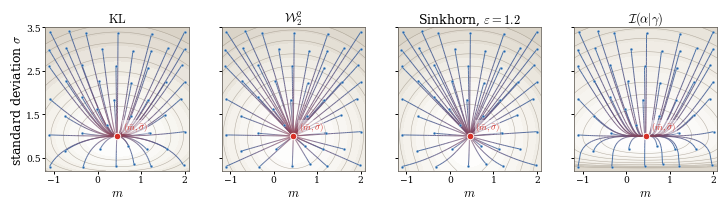

$\mathrm{KL}$: endpoint error=8.658e-04, largest energy increment=-4.842e-12
$\mathcal{W}_2^2$: endpoint error=4.313e-04, largest energy increment=-2.174e-10
Sinkhorn, $\varepsilon=1.2$: endpoint error=9.197e-06, largest energy increment=-1.339e-13
$\mathcal{I}(\alpha|\gamma)$: endpoint error=5.251e-04, largest energy increment=-3.519e-12


In [12]:
fig, axes = plt.subplots(1, 4, figsize=(7.25, 2.02), sharex=True, sharey=True)
for panel_index, (title, energy, trajectory_solver, final_time) in enumerate(PANEL_SPECS):
    draw_energy_background(axes[panel_index], energy)
    draw_flow_overlay(axes[panel_index], title, trajectory_solver, final_time)

axes[0].set_ylabel(r"standard deviation $\sigma$", labelpad=1.5)
fig.subplots_adjust(left=0.052, right=0.998, bottom=0.18, top=0.89, wspace=0.12)

save_pdf(fig, OUT / "flows.pdf", pad_inches=0.025)
fig.savefig(THUMBNAIL, dpi=220, bbox_inches="tight", pad_inches=0.025)
plt.show()
plt.close(fig)

# Numerical sanity checks: positivity, dissipation, and endpoint accuracy.
for title, energy, trajectory_solver, final_time in PANEL_SPECS:
    times = np.linspace(0.0, final_time, 220)
    trajectories = trajectory_solver(times)
    if np.min(trajectories[:, :, 1]) <= 0.0:
        raise RuntimeError(f"{title}: the standard deviation left the positive half-plane.")

    energy_values = energy(trajectories[:, :, 0], trajectories[:, :, 1])
    max_energy_increase = float(np.max(np.diff(energy_values, axis=1)))
    max_endpoint_error = float(
        np.max(np.linalg.norm(trajectories[:, -1, :] - TARGET, axis=1))
    )
    if max_energy_increase > 2e-9:
        raise RuntimeError(f"{title}: energy increased by {max_energy_increase:.3e}.")
    if max_endpoint_error > 1e-3:
        raise RuntimeError(f"{title}: endpoint error is {max_endpoint_error:.3e}.")
    print(
        f"{title}: endpoint error={max_endpoint_error:.3e}, "
        f"largest energy increment={max_energy_increase:.3e}"
    )


## Figure preview

The output below embeds the generated high-resolution thumbnail. The vector PDF used by the book is saved separately in the corresponding figure directory.

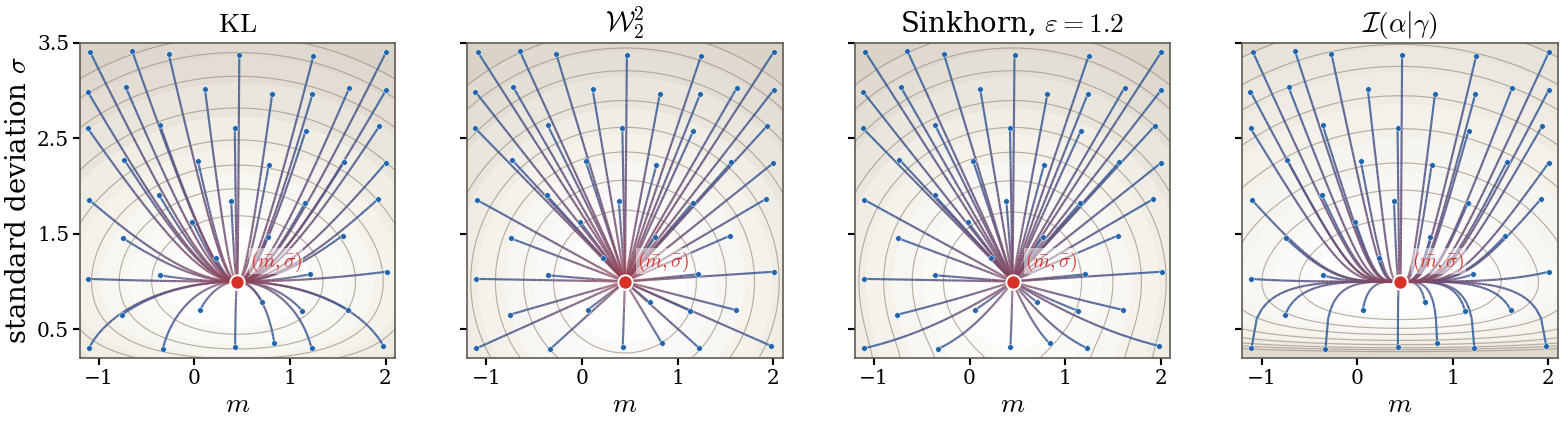

In [13]:
from IPython.display import Image, display

display(Image(filename=str(THUMBNAIL)))